## This notebook is used to analyze the variability of the genes in the Codex dataset.

In [1]:
import warnings
warnings.filterwarnings('ignore')
from tic.data import load_region, list_regions
from tic.metrics.variability import compute_pseudo_nonzero_gmm, compute_pseudo_nonzero_hybrid
from tic.plotting import plot_gene__distribution_with_tau

In [2]:
upmc_regions = list_regions('upmc')
charville_regions = list_regions('charville')
dfci_regions = list_regions('dfci')

example_upmc_region = upmc_regions[0]
example_charville_region = charville_regions[0]
example_dfci_region = dfci_regions[0]

example_upmc_region_adata = load_region(dataset='upmc',region_id=example_upmc_region)
example_charville_region_adata = load_region(dataset='charville',region_id=example_charville_region)
example_dfci_region_adata = load_region(dataset='dfci',region_id=example_dfci_region)

2025-06-13 10:51:56,572 INFO Extracting upmc_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_upmc
2025-06-13 10:51:56,572 | INFO     | tic.data.io | Extracting upmc_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_upmc


Skipping download; file exists: /Users/zhangjiahao/.cache/tic/codex_upmc/upmc_raw_data.zip


2025-06-13 10:51:59,883 INFO Extraction complete: /Users/zhangjiahao/.cache/tic/codex_upmc
2025-06-13 10:51:59,883 | INFO     | tic.data.io | Extraction complete: /Users/zhangjiahao/.cache/tic/codex_upmc
Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
2025-06-13 10:51:59,884 | INFO     | tic.data.codex.download | Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
2025-06-13 10:52:00,071 | INFO     | tic.data.codex.download | Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
2025-06-13 10:52:00,073 INFO Extracting charville_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_charville
2025-06-13 10:52:00,073 | INFO     | tic.data.io | Extracting charville_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_charville


Skipping download; file exists: /Users/zhangjiahao/.cache/tic/codex_charville/charville_raw_data.zip


2025-06-13 10:52:01,721 INFO Extraction complete: /Users/zhangjiahao/.cache/tic/codex_charville
2025-06-13 10:52:01,721 | INFO     | tic.data.io | Extraction complete: /Users/zhangjiahao/.cache/tic/codex_charville
Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
2025-06-13 10:52:01,722 | INFO     | tic.data.codex.download | Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
2025-06-13 10:52:01,854 | INFO     | tic.data.codex.download | Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
2025-06-13 10:52:01,856 INFO Extracting dfci_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_dfci
2025-06-13 10:52:01,856 | INFO     | tic.data.io | Extracting dfci_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_dfci


...

2025-06-13 10:52:05,595 INFO Extraction complete: /Users/zhangjiahao/.cache/tic/codex_upmc
2025-06-13 10:52:05,595 | INFO     | tic.data.io | Extraction complete: /Users/zhangjiahao/.cache/tic/codex_upmc
Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
2025-06-13 10:52:05,596 | INFO     | tic.data.codex.download | Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
2025-06-13 10:52:05,812 | INFO     | tic.data.codex.download | Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
Loaded upmc (UPMC_c001_v001_r001_reg001): 4360 cells * 22 biomarkers.
2025-06-13 10:52:05,835 | INFO     | tic.data.codex.loader | Loaded upmc (UPMC_c001_v001_r001_reg001): 4360 cells * 22 biomarkers.
2025-06-13 10:52:05,836 INFO Extracting charville_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_charville
2025-06-13 10:52:05,836 | INFO     | tic.data.io

Skipping download; file exists: /Users/zhangjiahao/.cache/tic/codex_charville/charville_raw_data.zip


2025-06-13 10:52:07,404 INFO Extraction complete: /Users/zhangjiahao/.cache/tic/codex_charville
2025-06-13 10:52:07,404 | INFO     | tic.data.io | Extraction complete: /Users/zhangjiahao/.cache/tic/codex_charville
Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
2025-06-13 10:52:07,405 | INFO     | tic.data.codex.download | Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
2025-06-13 10:52:07,507 | INFO     | tic.data.codex.download | Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
Loaded charville (Charville_c001_v001_r001_reg001): 2612 cells * 40 biomarkers.
2025-06-13 10:52:07,524 | INFO     | tic.data.codex.loader | Loaded charville (Charville_c001_v001_r001_reg001): 2612 cells * 40 biomarkers.
2025-06-13 10:52:07,525 INFO Extracting dfci_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_dfci
2025-06-

Skipping download; file exists: /Users/zhangjiahao/.cache/tic/codex_dfci/dfci_raw_data.zip


2025-06-13 10:52:07,865 INFO Extraction complete: /Users/zhangjiahao/.cache/tic/codex_dfci
2025-06-13 10:52:07,865 | INFO     | tic.data.io | Extraction complete: /Users/zhangjiahao/.cache/tic/codex_dfci
Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data
2025-06-13 10:52:07,865 | INFO     | tic.data.codex.download | Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data
Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data
2025-06-13 10:52:07,923 | INFO     | tic.data.codex.download | Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data
Loaded dfci (s271_c001_v001_r001_reg001): 1967 cells * 41 biomarkers.
2025-06-13 10:52:07,937 | INFO     | tic.data.codex.loader | Loaded dfci (s271_c001_v001_r001_reg001): 1967 cells * 41 biomarkers.


In [3]:
pt_nonzero_gmm, tau_values = compute_pseudo_nonzero_gmm(example_upmc_region_adata, return_tau=True)

print(tau_values)

CD11b         0.244693
CD14         -0.204091
CD15          0.046032
CD163        -0.693107
CD20          0.852753
CD21          2.069543
CD31          0.594957
CD34          0.244947
CD3e          0.702480
CD4           0.537709
CD45         -0.242103
CD45RA        1.021811
CD45RO        0.385722
CD68          0.184243
CD8           0.483556
CollagenIV    0.720293
HLA-DR        0.174477
Ki67          0.249446
PanCK        -0.628895
Podoplanin    0.524013
Vimentin      0.330571
aSMA         -0.104528
Name: tau_gmm, dtype: float64


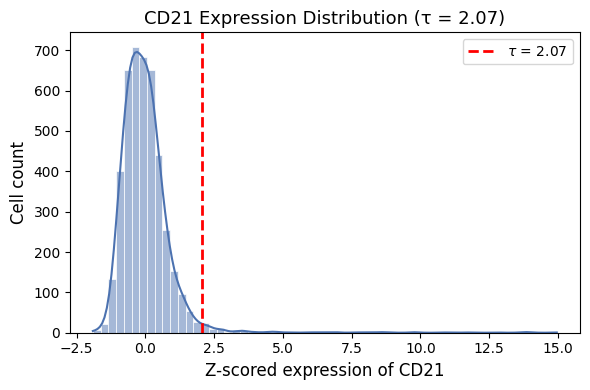

In [4]:
gene_name = "CD21"  
tau = tau_values[gene_name]

plot_gene__distribution_with_tau(example_upmc_region_adata, gene=gene_name, tau=tau)

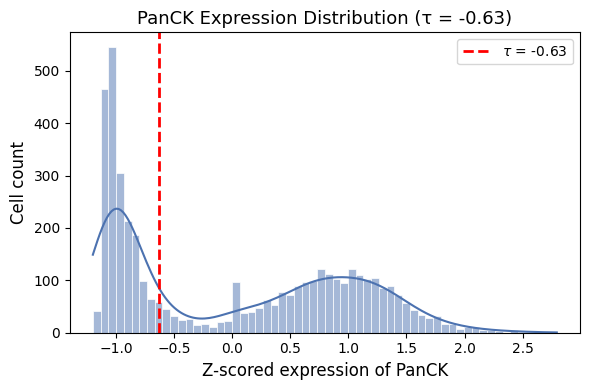

In [5]:
gene_name = "PanCK"  
tau = tau_values[gene_name]

plot_gene__distribution_with_tau(example_upmc_region_adata, gene=gene_name, tau=tau)

In [6]:
pt_nonzero_hybrid, tau_values, method = compute_pseudo_nonzero_hybrid(example_upmc_region_adata, return_tau=True)

print(method)
print(tau_values)

CD11b              gmm
CD14               gmm
CD15               gmm
CD163              gmm
CD20               gmm
CD21          fallback
CD31              otsu
CD34               gmm
CD3e              otsu
CD4                gmm
CD45               gmm
CD45RA             gmm
CD45RO             gmm
CD68               gmm
CD8               otsu
CollagenIV         gmm
HLA-DR             gmm
Ki67               gmm
PanCK              gmm
Podoplanin         gmm
Vimentin           gmm
aSMA               gmm
Name: method, dtype: object
CD11b         0.244693
CD14         -0.204091
CD15          0.046032
CD163        -0.693107
CD20          0.852753
CD21         -2.000000
CD31          2.150012
CD34          0.244947
CD3e          1.904282
CD4           0.537709
CD45         -0.242103
CD45RA        1.021811
CD45RO        0.385722
CD68          0.184243
CD8           2.313119
CollagenIV    0.720293
HLA-DR        0.174477
Ki67          0.249446
PanCK        -0.628895
Podoplanin    0.524013
Viment

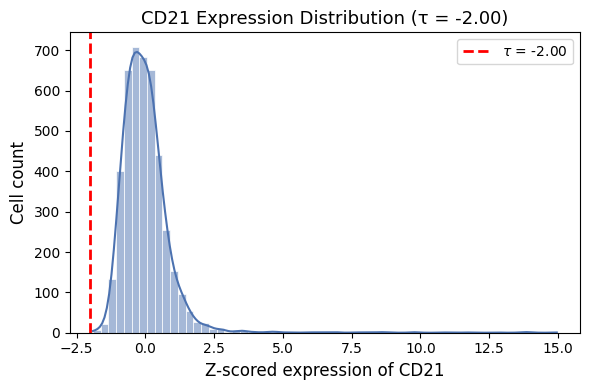

In [7]:
gene_name = "CD21"  
tau = tau_values[gene_name]

plot_gene__distribution_with_tau(example_upmc_region_adata, gene=gene_name, tau=tau)

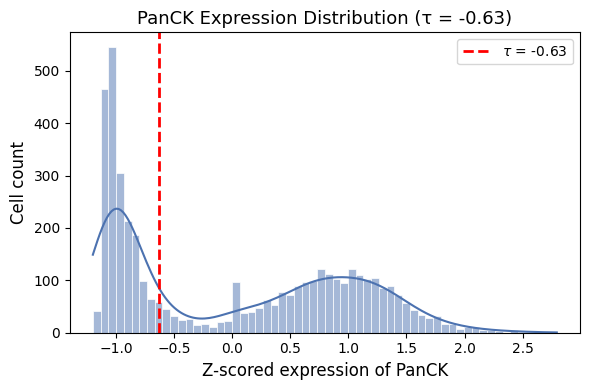

In [8]:
gene_name = "PanCK"  
tau = tau_values[gene_name]

plot_gene__distribution_with_tau(example_upmc_region_adata, gene=gene_name, tau=tau)